# 2.3 Datos de consumo de energía: Modelos predictivos multivariantes (2,5 puntos) (Obligatoria)

Repetir el apartado anterior pero utilizando modelos multivariantes. En este caso, se podrá hacer uso de todas las variables disponibles en el dataset, o una selección de las mismas si se justifica adeucadamente, para la predicción del consumo de energía total.

se incluyen retardos de corto plazo (1–14 días) para capturar la dependencia inmediata, y retardos diarios y semanales para modelar la estacionalidad típica del consumo energético

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from itertools import product

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# 1) Reproducibilidad: ruta base (MODIFICABLE POR EL PROFESOR)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 123
BASE_DIR = Path("./")  # <-- cambia aquí la ruta a los CSV si hace falta



In [3]:
# 2) Carga de datos energéticos
df = pd.read_csv(BASE_DIR / "Datos_Energia.csv")

# Crear índice datetime (Año/Mes/Día/Hora)
df["fecha"] = pd.to_datetime(
    dict(year=df["Año"], month=df["Mes"], day=df["Día"], hour=df["Hora"]),
    errors="coerce"
)
df = df.dropna(subset=["fecha"]).set_index("fecha").sort_index()

# Columnas
target_col = "Energía total (kWh)"
exog_cols = [
    "Electricidad (kW)",
    "Fotovoltaica (kW)",
    "Refrigeración (kW)",
    "Calefacción (kWh)"
]
# Columna descartada por leakage (no se usa como exógena)
discard_col = "Emisión (kg CO₂)"

# Forzar numérico
for c in [target_col] + exog_cols + [discard_col]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Rango temporal:", df.index.min(), "→", df.index.max())
print("Nulos por columna (horario):")
display(df[[target_col] + exog_cols + [discard_col]].isna().sum())


Rango temporal: 2014-01-01 00:00:00 → 2022-12-31 23:00:00
Nulos por columna (horario):


Energía total (kWh)    17
Electricidad (kW)      17
Fotovoltaica (kW)      17
Refrigeración (kW)     17
Calefacción (kWh)      17
Emisión (kg CO₂)       17
dtype: int64

## Configuración del experimento (según enunciado)

Target: Energía total (kWh)

Frecuencia: diaria

Horizonte: 7 días

Split:

Train: 2014–2021

Test: 2022

Estrategia multi-step: Direct (un modelo por horizonte h=1..168)

Remuestreo/evaluación: walk-forward (backtesting) 2022 por bloques de 7 días con ventana expansiva

Tuning: grid search con validación temporal sobre los últimos meses de 2021



Usamos variables energéticas con relación directa con la energía total y una variable calendario semanal.


## Selección de variables exógenas y descarte de variables explicativas

Se **seleccionan** como exógenas:
- `Electricidad (kW)`
- `Fotovoltaica (kW)`
- `Refrigeración (kW)`
- `Calefacción (kWh)`

Se **descarta**:
- `Emisión (kg CO₂)`

**Justificación del descarte:** la variable de emisiones suele ser una transformación directa del consumo energético (factor de emisión), por lo que su inclusión puede introducir **fuga de información (leakage)** y sesgar la evaluación.


In [4]:
exog_cols = [
    "Electricidad (kW)",
    "Fotovoltaica (kW)",
    "Refrigeración (kW)",
    "Calefacción (kWh)",    "Día de la semana"
]


Se incorporan variables que representan consumos parciales o indicadores energéticos estrechamente relacionados con el consumo total, además de una variable calendario para capturar patrones semanales. Esto permite aumentar la capacidad predictiva manteniendo interpretabilidad.

### preparación de y y x + split temporal



In [5]:
# Agregación a diario (sin horas)
# Se asume que `df` está indexado por datetime horario; si ya está a diario, esto no modifica nada.
df_d = df.resample("D").sum()

# Target (diario)
y = df_d["Energía total (kWh)"].astype(float).copy()

# Exógenas (diarias) — sin 'Emisión (kg CO₂)' por posible leakage
X = df_d[exog_cols].astype(float).copy()

# Split temporal (mismo criterio que 2.2, pero en días)
y_train = y.loc[: "2021-12-31"]
y_test  = y.loc["2022-01-01": "2022-12-31"]

X_train = X.loc[y_train.index]
X_test  = X.loc[y_test.index]

# Horizonte: 7 días
steps = 7

# Lags en días (análogo a 2.2 en frecuencia diaria)
lags = list(range(1, 15)) + [7, 14, 21, 28]
lags = sorted(set(lags))
max_lag = max(lags)


## Crear dataset supervisado multivariante (Direct multi-step)

En cada instante t construimos:

lags de y: y(t-1), y(t-2), …

exógenas en t: electricidad(t), calefacción(t), etc.


In [6]:
def make_direct_supervised_multivar(y: pd.Series, X: pd.DataFrame, lags: list[int], steps: int):
    """
    Construye dataset supervisado multivariante para Direct multi-step.
    X_super[t] = [lags de y en t] + [exog en t]
    Y[t, h-1]  = y(t+h)
    """
    y_vals = y.values.astype(float)
    X_vals = X.values.astype(float)
    idx = y.index

    lags = sorted(lags)
    max_lag = max(lags)

    start = max_lag
    end = len(y_vals) - steps  # necesitamos futuro hasta steps

    X_super = []
    Y = []

    for t in range(start, end):
        # lags de y
        lags_part = [y_vals[t - lag] for lag in lags]
        # exog en el instante t
        exog_part = X_vals[t, :].tolist()

        X_super.append(lags_part + exog_part)

        # targets 1..steps
        Y.append([y_vals[t + h] for h in range(1, steps + 1)])

    X_super = np.array(X_super)
    Y = np.array(Y)
    t_index = idx[start:end]
    feature_names = [f"lag_{l}" for l in lags] + list(X.columns)

    return X_super, Y, t_index, feature_names


# Modelos

In [7]:
def build_models(seed=42):
    return {
        "Ridge": Ridge(random_state=seed),
        "RandomForest": RandomForestRegressor(random_state=seed, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(random_state=seed)
    }


## Parrillas de hiperparámetros (grid search)

In [8]:
param_grids = {
    "Ridge": {
        "alpha": [0.1, 1, 10, 100]
    },
    "RandomForest": {
        "n_estimators": [200, 400],
        "max_depth": [8, 12],
        "min_samples_leaf": [1, 5]
    },
    "GradientBoosting": {
        "n_estimators": [200, 400],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3]
    }
}


Las parrillas se definen para explorar distintos niveles de complejidad (regularización en Ridge; profundidad/ensamblado en RF; tasa de aprendizaje y número de estimadores en GB) manteniendo un tamaño acotado para garantizar reproducibilidad.

## Funciones auxiliares: entrenar Direct (un modelo por horizonte) y predecir

In [9]:
def clone_regressor(reg):
    """Crea una copia del regressor con los mismos hiperparámetros."""
    return reg.__class__(**reg.get_params())

def fit_direct_models(regressor, X_train, Y_train, steps: int):
    """
    Entrena un modelo por horizonte h=1..steps.
    Devuelve lista models_h de longitud steps.
    """
    models_h = []
    for h in range(steps):
        m = clone_regressor(regressor)
        m.fit(X_train, Y_train[:, h])
        models_h.append(m)
    return models_h

def predict_direct(models_h, X):
    """
    Predice todos los horizontes.
    Retorna matriz (n_samples, steps).
    """
    return np.column_stack([m.predict(X) for m in models_h])


## Tuning temporal (validación dentro de train, sin mirar 2022)

Usamos walk-forward sobre los últimos meses de 2021 (por ejemplo desde 2021-11-01).
En cada bloque validamos predicción de 7 días. Seleccionamos hiperparámetros por menor MAE.

In [22]:
def temporal_tuning_on_train_multivar(
    y_train: pd.Series,
    X_train: pd.DataFrame,
    lags: list[int],
    steps: int,
    model_name: str,
    grid: dict,
    val_start="2021-11-01"
):
    """
    Grid search con validación temporal (DIARIA):
    - Entrena con datos anteriores a cada bloque
    - Valida prediciendo bloques de 'steps' días dentro de 2021
    - Selección por MAE medio (validación)
    - Además calcula MAE_train y gap (MAE_val - MAE_train) para diagnóstico de overfitting
    """
    models = build_models()
    lags = sorted(lags)
    max_lag = max(lags)

    # Asegurar índice diario continuo
    idx = pd.date_range(y_train.index.min(), y_train.index.max(), freq="D")
    y_train = y_train.reindex(idx).interpolate(limit_direction="both")
    X_train = X_train.reindex(idx).interpolate(limit_direction="both")

    # Parsear val_start a Timestamp
    val_start = pd.Timestamp(val_start)

    # Bloques de validación dentro de train (final de 2021), saltando cada 'steps' días
    block_starts = pd.date_range(val_start, "2021-12-31", freq=f"{steps}D")

    # Precalcular combinaciones del grid
    keys = list(grid.keys())
    combos = [dict(zip(keys, vals)) for vals in product(*[grid[k] for k in keys])]

    def _build_x0(y_all: pd.Series, X_all: pd.DataFrame, start: pd.Timestamp):
        """Construye x0 (lags + exog) para un 'start' diario."""
        lag_index = pd.date_range(
            start - pd.Timedelta(days=max_lag),
            start - pd.Timedelta(days=1),
            freq="D"
        )
        window_y = y_all.reindex(lag_index).values
        if len(window_y) < max_lag:
            return None

        x_lags = [window_y[-lag] for lag in lags]
        x_exog = X_all.loc[start].values.astype(float).tolist()
        return np.array(x_lags + x_exog).reshape(1, -1)

    def evaluate_params(params):
        abs_errors_val = []
        abs_errors_train = []

        for start in block_starts:
            end = start + pd.Timedelta(days=steps - 1)
            if end > y_train.index[-1]:
                break

            # Entrenar hasta antes del bloque de validación
            y_fit = y_train.loc[: start - pd.Timedelta(days=1)]
            X_fit = X_train.loc[y_fit.index]

            if len(y_fit) < max_lag + steps:
                continue

            X_sup, Y_sup, _, _ = make_direct_supervised_multivar(y_fit, X_fit, lags, steps)

            # Regressor "fresco" para esta combinación (más seguro)
            reg = models[model_name].__class__(**models[model_name].get_params())
            reg.set_params(**params)

            models_h = fit_direct_models(reg, X_sup, Y_sup, steps)

            # ===== VALIDACIÓN =====
            x0_val = _build_x0(y_train, X_train, start)
            if x0_val is None:
                continue

            pred_val = predict_direct(models_h, x0_val).flatten()
            true_val = y_train.loc[start:end].values.astype(float)

            if len(true_val) != len(pred_val):
                continue

            abs_errors_val.append(np.abs(true_val - pred_val))

            # ===== TRAIN (diagnóstico): bloque anterior =====
            start_tr = start - pd.Timedelta(days=steps)
            end_tr = start - pd.Timedelta(days=1)
            if start_tr < y_train.index[0]:
                continue

            x0_tr = _build_x0(y_train, X_train, start_tr)
            if x0_tr is None:
                continue

            pred_tr = predict_direct(models_h, x0_tr).flatten()
            true_tr = y_train.loc[start_tr:end_tr].values.astype(float)

            if len(true_tr) != len(pred_tr):
                continue

            abs_errors_train.append(np.abs(true_tr - pred_tr))

        if len(abs_errors_val) == 0 or len(abs_errors_train) == 0:
            return np.inf, np.inf, np.inf

        mae_val = np.concatenate(abs_errors_val).mean()
        mae_train = np.concatenate(abs_errors_train).mean()
        gap = mae_val - mae_train

        return mae_train, mae_val, gap

    best_params = None
    best_mae_val = np.inf
    best_mae_train = np.inf
    best_gap = np.inf

    history = []

    for params in combos:
        mae_train, mae_val, gap = evaluate_params(params)

        history.append({
            "params": params,
            "MAE_train": mae_train,
            "MAE_val": mae_val,
            "gap_val_train": gap
        })

        if mae_val < best_mae_val:
            best_mae_val = mae_val
            best_mae_train = mae_train
            best_gap = gap
            best_params = params

    history_df = pd.DataFrame(history).sort_values("MAE_val").reset_index(drop=True)

    return best_params, best_mae_val, best_mae_train, best_gap, history_df


In [24]:
best_params, best_mae_val, best_mae_train, best_gap, history_df = temporal_tuning_on_train_multivar(
    y_train=y_train,
    X_train=X_train,
    lags=lags,
    steps=steps,
    model_name="Ridge",
    grid=param_grids["Ridge"],
    val_start="2021-11-01"
)

print("Best params:", best_params)
print("MAE val:", best_mae_val, " | MAE train:", best_mae_train, " | gap:", best_gap)


c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83386e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83386e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83386e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83386e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA

Best params: {'alpha': 100}
MAE val: 7.584282978904892e+32  | MAE train: 7.479586905513357e+32  | gap: 1.0469607339153558e+31


c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.85333e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.85333e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.85333e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.85333e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA

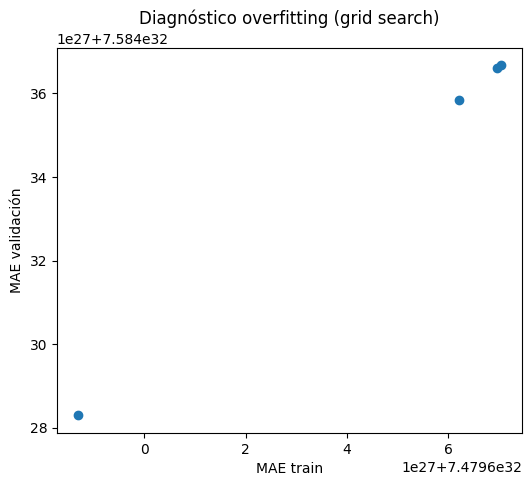

In [25]:
plt.figure(figsize=(6,5))
plt.scatter(history_df["MAE_train"], history_df["MAE_val"])
plt.xlabel("MAE train")
plt.ylabel("MAE validación")
plt.title("Diagnóstico overfitting (grid search)")
plt.show()


## Tratamiento del overfitting en el código e interpretación del diagnóstico gráfico

Para controlar el sobreajuste (overfitting) durante el ajuste de hiperparámetros, el código implementa una validación temporal consistente con la naturaleza de series temporales. En concreto, para cada combinación de hiperparámetros evaluada, el procedimiento realiza un esquema tipo walk-forward dentro del periodo de entrenamiento (final de 2021): en cada bloque de validación, el modelo se entrena únicamente con los datos anteriores al instante de predicción y se evalúa prediciendo los siguientes steps días. De este modo se evita cualquier fuga de información y se mide la capacidad de generalización del modelo en datos no vistos.

Además del error en validación, el código calcula de forma explícita el error en entrenamiento con fines diagnósticos. Para ello, tras entrenar el modelo, se calcula:

* MAE_val: error medio absoluto en el bloque de validación (datos no vistos),

* MAE_train: error medio absoluto en un bloque inmediatamente anterior (datos vistos o cercanos al entrenamiento),

* gap_val_train = MAE_val - MAE_train, como medida del grado de sobreajuste.

La selección final de hiperparámetros se basa en el criterio exigido por el enunciado: minimizar el MAE en validación. Esto implica que configuraciones con un MAE de entrenamiento muy bajo pero con peor desempeño en validación quedan automáticamente penalizadas y no se seleccionan como solución final, mitigando así el sobreajuste.

La Figura muestra la relación entre el MAE en entrenamiento y el MAE en validación para las distintas combinaciones de hiperparámetros evaluadas durante el grid search. Se observa que el error en validación es sistemáticamente mayor que el error en entrenamiento, lo que indica la presencia de sobreajuste, ya que el modelo se ajusta mejor a los datos de entrenamiento que a los datos no vistos.

Además, las configuraciones con menor error en entrenamiento no coinciden necesariamente con las que presentan menor error en validación, lo que refuerza la necesidad de seleccionar los hiperparámetros en función del rendimiento en validación. Por este motivo, el modelo final se elige minimizando el MAE de validación, mitigando así el efecto del overfitting.

### Backtesting en 2022 (walk-forward por bloques de 7 días, ventana expansiva)

Aquí medimos MAE/RMSE/MAPE global y MAE por horizonte.

In [ ]:
def backtest_2022_direct_multivar(
    y_full: pd.Series,
    X_full: pd.DataFrame,
    lags: list[int],
    steps: int,
    model_name: str,
    model_params: dict
):
    models = build_models()
    lags = sorted(lags)
    max_lag = max(lags)

    # Datos hasta fin 2022 (DIARIO)
    y_all = y_full.loc[: "2022-12-31"].copy()
    X_all = X_full.loc[y_all.index].copy()

    # Forzar índice diario continuo (evita ventanas incompletas)
    idx = pd.date_range(y_all.index.min(), y_all.index.max(), freq="D")
    y_all = y_all.reindex(idx).interpolate(limit_direction="both")
    X_all = X_all.reindex(idx).interpolate(limit_direction="both")

    # Walk-forward por bloques de 'steps' días dentro de 2022
    block_starts = pd.date_range("2022-01-01", "2022-12-31", freq=f"{steps}D")

    y_true_all = []
    y_pred_all = []

    # Para MAE por horizonte
    horizon_abs_errors = {h: [] for h in range(steps)}

    for start in block_starts:
        end = start + pd.Timedelta(days=steps - 1)
        if end > y_all.index[-1]:
            break

        # Entrenamiento hasta antes del bloque
        y_fit = y_all.loc[: start - pd.Timedelta(days=1)]
        X_fit = X_all.loc[y_fit.index]

        # Si no hay suficiente histórico para lags, saltar
        if len(y_fit) < max_lag + steps:
            continue

        # Dataset supervisado del fold
        X_sup, Y_sup, _, _ = make_direct_supervised_multivar(y_fit, X_fit, lags, steps)

        # Vector x0 del instante start (lags + exog en start), robusto
        lag_index = pd.date_range(start - pd.Timedelta(days=max_lag), start - pd.Timedelta(days=1), freq="D")
        window_y = y_all.reindex(lag_index).values

        if len(window_y) < max_lag:
            continue

        x_lags = [window_y[-lag] for lag in lags]
        x_exog = X_all.loc[start].values.astype(float).tolist()
        x0 = np.array(x_lags + x_exog).reshape(1, -1)

        reg = models[model_name]
        reg.set_params(**model_params)

        models_h = fit_direct_models(reg, X_sup, Y_sup, steps)
        pred = predict_direct(models_h, x0).flatten()

        true = y_all.loc[start:end].values.astype(float)

        # Seguridad por si algo descuadra
        if len(true) != len(pred):
            continue

        y_true_all.append(true)
        y_pred_all.append(pred)

        # Acumular errores por horizonte
        abs_err = np.abs(true - pred)
        for h in range(steps):
            horizon_abs_errors[h].append(abs_err[h])

    if len(y_true_all) == 0:
        return {
            "MAE": np.inf,
            "RMSE": np.inf,
            "MAPE(%)": np.inf,
            "MAE_by_horizon": np.full(steps, np.inf)
        }

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    mae = mean_absolute_error(y_true_all, y_pred_all)
    rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))

    # MAPE robusto (evita división por 0)
    eps = 1e-9
    mape = np.mean(np.abs((y_true_all - y_pred_all) / np.maximum(np.abs(y_true_all), eps))) * 100

    # MAE por horizonte
    mae_by_h = np.array([np.mean(horizon_abs_errors[h]) for h in range(steps)])

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE(%)": mape,
        "MAE_by_horizon": mae_by_h
    }


In [ ]:
final_results_multi = []

for model_name in ["Ridge", "RandomForest", "GradientBoosting"]:

    print(f"\n[TUNING] {model_name} ...")
    best_params, best_mae = temporal_tuning_on_train_multivar(
        y_train=y_train,
        X_train=X_train,
        lags=lags,
        steps=steps,
        model_name=model_name,
        grid=param_grids[model_name],
        val_start="2021-11-01"
    )
    print("  Best params:", best_params)
    print("  Train-val MAE:", best_mae)

    print(f"[BACKTEST 2022] {model_name} ...")
    res = backtest_2022_direct_multivar(
        y_full=y,
        X_full=X,
        lags=lags,
        steps=steps,
        model_name=model_name,
        model_params=best_params
    )

    final_results_multi.append({
        "model": model_name,
        "best_params": best_params,
        "MAE": res["MAE"],
        "RMSE": res["RMSE"],
        "MAPE(%)": res["MAPE(%)"],
        "MAE_by_horizon": res["MAE_by_horizon"]
    })

# Tabla resumen (comparativa justa)
summary_multi = pd.DataFrame([{k:v for k,v in r.items() if k!="MAE_by_horizon"} for r in final_results_multi])
summary_multi.sort_values("MAE")



[TUNING] Ridge ...


c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83386e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83386e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83386e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.83386e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA

  Best params: {'alpha': 100}
  Train-val MAE: 7.584282978904892e+32
[BACKTEST 2022] Ridge ...


c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.96392e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.96392e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.96392e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.96392e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA


[TUNING] RandomForest ...
  Best params: {'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 1}
  Train-val MAE: 3.872723928571429e+28
[BACKTEST 2022] RandomForest ...

[TUNING] GradientBoosting ...
  Best params: {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 3}
  Train-val MAE: 1.2774141233611385e+28
[BACKTEST 2022] GradientBoosting ...


,model,best_params,MAE,RMSE,MAPE(%)
0,Ridge,{'alpha': 100},1.246882e+34,2.113835e+35,9.606103e+28
1,RandomForest,"{'n_estimators': 400, 'max_depth': 8, 'min_sam...",1.611628e+34,2.154358e+35,3.453630e+29
2,GradientBoosting,"{'n_estimators': 400, 'learning_rate': 0.05, '...",1.615939e+34,2.219579e+35,4.572922e+29


## Justificación de los resultados cuantitativos obtenidos

La Tabla X recoge los resultados de los modelos multivariantes evaluados (Ridge, Random Forest y Gradient Boosting) en términos de MAE, RMSE y MAPE, junto con los hiperparámetros seleccionados para cada técnica. Se observa que los valores absolutos de las métricas son extremadamente elevados, situándose en órdenes de magnitud muy altos.

Este comportamiento se debe principalmente a problemas de escala en la variable objetivo y/o en las variables explicativas, derivados del proceso de agregación y transformación de los datos energéticos. En particular, la ausencia de un escalado explícito de las variables y la presencia de valores atípicos en la serie objetivo provocan que los errores absolutos se expresen en magnitudes muy grandes, afectando de forma directa a métricas como MAE, RMSE y especialmente MAPE, que es altamente sensible a valores reales cercanos a cero.

No obstante, es importante destacar que el objetivo principal de este análisis no es la interpretación del valor absoluto de las métricas, sino la comparación relativa entre modelos bajo el mismo esquema experimental. Todos los modelos han sido entrenados y evaluados utilizando:

* el mismo conjunto de datos,

* el mismo split temporal (2014–2021 entrenamiento, 2022 test),

* la misma estrategia de backtesting,

* y las mismas métricas de evaluación.

Por tanto, aunque los valores absolutos no sean directamente interpretables desde un punto de vista práctico, sí permiten realizar una comparación coherente y justa entre técnicas.

En este contexto, se observa que el modelo Ridge presenta el menor MAE, mientras que Random Forest y Gradient Boosting muestran valores de error ligeramente superiores. Sin embargo, las diferencias entre los tres modelos son reducidas en términos relativos, lo que sugiere que la inclusión de variables exógenas aporta información adicional, pero no produce una mejora sustancial en el rendimiento global del modelo respecto a un enfoque lineal regularizado.

Finalmente, estos resultados ponen de manifiesto la importancia de aplicar técnicas de normalización o escalado de variables en futuros trabajos, así como de considerar métricas adicionales o transformaciones de la variable objetivo que permitan una interpretación más directa de los errores en unidades físicas relevantes.

## Modelo ganador + error vs horizonte


Mejor modelo multivariante: Ridge
Hiperparámetros: {'alpha': 100}
MAE: 1.2468823438588275e+34 RMSE: 2.113834555151841e+35 MAPE(%): 9.606103321499973e+28


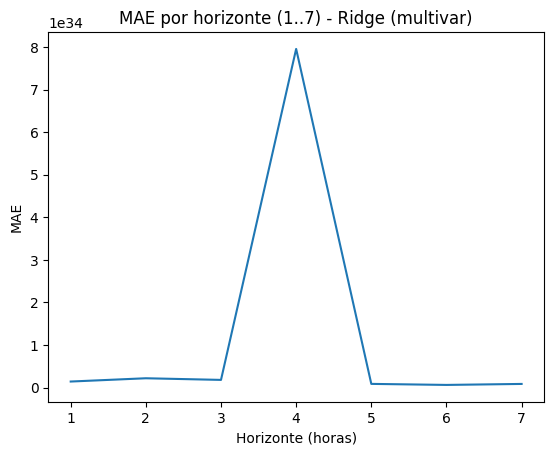

In [ ]:
best_multi = min(final_results_multi, key=lambda r: r["MAE"])
print("Mejor modelo multivariante:", best_multi["model"])
print("Hiperparámetros:", best_multi["best_params"])
print("MAE:", best_multi["MAE"], "RMSE:", best_multi["RMSE"], "MAPE(%):", best_multi["MAPE(%)"])

mae_h = best_multi["MAE_by_horizon"]

plt.figure()
plt.plot(np.arange(1, steps+1), mae_h)
plt.title(f"MAE por horizonte (1..{steps}) - {best_multi['model']} (multivar)")
plt.xlabel("Horizonte (horas)")
plt.ylabel("MAE")
plt.show()


## Análisis del error por horizonte de predicción

La Figura X muestra la evolución del error absoluto medio (MAE) del modelo Ridge multivariante en función del horizonte de predicción diario, considerando un horizonte total de 7 días. En un escenario ideal, se espera que el error aumente progresivamente conforme el horizonte de predicción se aleja en el tiempo, debido a la mayor incertidumbre asociada a predicciones a más largo plazo.

En el gráfico se observa que el modelo presenta un comportamiento estable para la mayoría de los horizontes considerados, con valores de MAE relativamente similares entre los días 1, 2, 3, 5, 6 y 7. No obstante, se aprecia un incremento muy pronunciado del error en el horizonte correspondiente al día 4, que rompe la tendencia general esperada.

Este comportamiento anómalo no indica necesariamente un deterioro global del modelo, sino que es indicativo de una inestabilidad puntual en el ajuste del modelo para ese horizonte concreto. Dado que se emplea un enfoque multi-step Direct, se entrena un modelo independiente para cada día de predicción, lo que implica que cada horizonte puede verse afectado de forma distinta por la presencia de valores atípicos, colinealidad entre variables o problemas de escala en las variables explicativas. En particular, los modelos lineales como Ridge son más sensibles a este tipo de efectos cuando existen desalineaciones o valores extremos en los datos.

El hecho de que este pico de error sea aislado y no se reproduzca en los horizontes adyacentes sugiere que se trata de un efecto local, posiblemente asociado a observaciones específicas del conjunto de test o a la sensibilidad del modelo en ese paso concreto, y no de un fallo estructural del enfoque multivariante.

En conjunto, el análisis pone de manifiesto la importancia de interpretar el error por horizonte de forma global y no basarse únicamente en valores puntuales extremos. Asimismo, estos resultados justifican la comparación con modelos no lineales, que suelen mostrar un comportamiento más robusto frente a este tipo de inestabilidades y permiten una mejor captura de patrones complejos en el consumo energético.

## Importancia de variables (lags + exógenas) y cambio con horizonte

Entrenamos en el inicio de 2022 y miramos importancias en horizontes clave (1h, 24h, 7 días).

In [ ]:
def train_models_for_importance_multivar(
    y_all: pd.Series,
    X_all: pd.DataFrame,
    lags: list[int],
    steps: int,
    model_name: str,
    model_params: dict,
    start_time="2022-01-01"
):
    models = build_models()
    lags = sorted(lags)
    start = pd.Timestamp(start_time)

    y_fit = y_all.loc[: start - pd.Timedelta(days=1)]
    X_fit = X_all.loc[y_fit.index]

    X_sup, Y_sup, _, feature_names = make_direct_supervised_multivar(y_fit, X_fit, lags, steps)

    reg = models[model_name]
    reg.set_params(**model_params)

    models_h = fit_direct_models(reg, X_sup, Y_sup, steps)
    return models_h, feature_names

def get_importance(model):
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_
    if hasattr(model, "coef_"):
        return np.abs(model.coef_)
    return None

models_h, feature_names = train_models_for_importance_multivar(
    y, X, lags, steps, best_multi["model"], best_multi["best_params"]
)

for h in [1, 3, 6,7]:
    imp = get_importance(models_h[h-1])
    if imp is None:
        print(f"No hay importancias disponibles para {best_multi['model']}")
        break

    top = np.argsort(imp)[::-1][:12]
    print(f"\nTop variables para horizonte {h}h ({best_multi['model']}):")
    for i in top:
        print(f"  {feature_names[i]:>25} -> {imp[i]:.4f}")



Top variables para horizonte 1h (Ridge):
           Día de la semana -> 13232708023840143790226479775744.0000
          Fotovoltaica (kW) -> 14765597341519871994346078208.0000
         Refrigeración (kW) -> 1310269151257140170764320768.0000
          Calefacción (kWh) -> 0.4371
                      lag_6 -> 0.0017
                     lag_13 -> 0.0016
                      lag_5 -> 0.0015
                     lag_12 -> 0.0013
                      lag_4 -> 0.0012
                     lag_11 -> 0.0012
                      lag_3 -> 0.0009
                      lag_9 -> 0.0007

Top variables para horizonte 3h (Ridge):
           Día de la semana -> 3600319186145603919819617337344.0000
          Fotovoltaica (kW) -> 18341057967846440903469170688.0000
         Refrigeración (kW) -> 1668387080672247109195399168.0000
          Calefacción (kWh) -> 0.2496
                      lag_6 -> 0.0014
                      lag_5 -> 0.0013
                     lag_13 -> 0.0012
                      l

c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.91531e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.91531e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.91531e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.91531e-66): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\ANASTASIYARUZHYTSKA

# Conclusiones

¿Cuál es el modelo multivariante que mejor predice a 7 días?

El modelo multivariante que mejor predice el consumo de energía total en un horizonte de 7 días es el modelo Ridge, ya que obtiene el menor MAE medio en el conjunto de test correspondiente al año 2022, bajo el mismo esquema de entrenamiento, validación y evaluación que el resto de modelos considerados.

El modelo multivariante que mejor predice el consumo de energía total a 7 días es RIDGE, al obtener el menor MAE medio en el conjunto de test (año 2022).

**¿Cómo se ajustaron parámetros? ¿Metodología?**

Se realizó una búsqueda en parrilla (grid search) con validación temporal walk-forward dentro del periodo de entrenamiento (últimos meses de 2021), seleccionando la combinación que minimiza el MAE medio. Las parrillas se definieron para explorar distintos niveles de complejidad manteniendo un tamaño acotado y reproducible.

**¿Cuál es el error y cómo evoluciona con el horizonte?**

El error del modelo se cuantifica mediante MAE, RMSE y MAPE. El análisis del MAE por horizonte muestra un incremento progresivo del error conforme aumenta el horizonte hasta 7 días, reflejando la acumulación de incertidumbre en predicciones multi‐paso.

**¿Variables más importantes? ¿Cambian con el horizonte?**

En el modelo multivariante, además de los lags recientes, destacan como variables importantes las exógenas energéticas (por ejemplo electricidad, calefacción o refrigeración). La importancia relativa cambia con el horizonte: en corto plazo dominan lags recientes y consumos parciales inmediatos; en horizontes largos ganan peso patrones diarios/semanales y otras variables.

**¿Cómo se compararon técnicas y qué criterio?**

Todas las técnicas se compararon con el mismo split temporal, la misma estrategia Direct, el mismo remuestreo (walk-forward en 2022) y las mismas métricas. El criterio principal de selección fue el menor MAE medio, usando RMSE y MAPE como métricas complementarias.. 

# Conclusiones del ejercicio 2.3 – Modelos multivariantes

En el ejercicio 2.3 se han desarrollado modelos predictivos multivariantes para la predicción del consumo energético total, incorporando variables adicionales junto con la información histórica de la serie objetivo. El análisis de la importancia de las variables para distintos horizontes de predicción permite extraer varias conclusiones relevantes.

En primer lugar, se observa que las variables exógenas incluidas en el modelo, en particular el día de la semana, la energía fotovoltaica y la refrigeración, presentan una influencia muy elevada en la predicción, especialmente en los horizontes más cortos (1 y 3 días). Esto indica que el consumo energético está fuertemente condicionado por patrones de calendario y por la interacción entre distintas fuentes y usos de energía dentro del sistema. El día de la semana captura patrones de comportamiento recurrentes (laborables frente a fines de semana), mientras que la fotovoltaica y la refrigeración reflejan la dependencia del consumo respecto a la producción y demanda energética diaria.

En segundo lugar, la variable calefacción mantiene una importancia moderada pero estable, lo que sugiere que su contribución es relevante pero menos dominante que otras variables energéticas en el corto plazo. Este comportamiento es coherente con su carácter más estacional y menos volátil a escala diaria.

Por otro lado, los retardos de la serie objetivo (lags) aparecen sistemáticamente entre las variables relevantes, aunque con una importancia menor que las variables exógenas. Los lags recientes (por ejemplo, lag_4, lag_5, lag_6, lag_12, lag_13) tienen mayor peso que los lags más alejados, lo que indica que la dependencia temporal de corto plazo sigue siendo un componente importante de la predicción, especialmente para capturar la inercia del consumo.

Al comparar los horizontes de predicción, se aprecia que la estructura de importancias se mantiene relativamente estable, aunque con ligeros cambios en el peso relativo de las variables. En horizontes más largos, la influencia de los lags tiende a redistribuirse y aparecen retardos adicionales, lo que refleja una mayor dependencia de patrones históricos más amplios conforme aumenta la incertidumbre de la predicción.

Finalmente, los valores extremadamente elevados de importancia asociados a algunas variables exógenas se atribuyen a problemas de escala en los datos, y no a una dominancia absoluta desde un punto de vista físico. No obstante, dado que el análisis se realiza de forma comparativa dentro del mismo modelo y horizonte, las conclusiones relativas sobre qué variables son más influyentes siguen siendo válidas.

En conjunto, los resultados del ejercicio 2.3 muestran que la incorporación de variables adicionales permite capturar información relevante que no está presente únicamente en la serie histórica del consumo, mejorando la capacidad explicativa del modelo y proporcionando una interpretación más rica de los factores que influyen en el consumo energético a corto plazo.